In [105]:
%load_ext autoreload
%autoreload 2

import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import qlbm
from qlbm.initial_conditions import (
    get_gaussian_initial_distribution,
    get_gaussian_2d_initial_distribution,
    get_uniform_velocity_field,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
# ── Experiment parameters ──────────────────────────────────────────────────────
NUM_TRIALS  = 5                                   # increase if runs fast
SHOT_COUNTS = np.unique(np.logspace(1, 6, 20).astype(int))

## 1D — Periodic Gaussian Hill (D1Q3, 8 sites)

In [107]:
# ── 1D config ─────────────────────────────────────────────────────────────────
SITES_1D = 8

links_1d   = [[0], [-1], [1]]
weights_1d = [2/3, 1/6, 1/6]
cs_1d      = 1 / np.sqrt(3)

initial_density_1d = get_gaussian_initial_distribution(
    sites=SITES_1D,
    center=SITES_1D / 2,
    width=1.5,
    amplitude=0.9,
    background=0.1,
)
velocity_field_1d = get_uniform_velocity_field(SITES_1D, velocity=0.0)

config_1d = [(1, velocity_field_1d, links_1d, weights_1d, cs_1d, None)]

In [108]:
# ── 1D ideal reference density (statevector) ──────────────────────────────────
with tempfile.NamedTemporaryFile(suffix='.csv', delete=False, mode='w') as f:
    tmp_1d = f.name

qlbm.simulate_flow(initial_density_1d, config_1d, tmp_1d)
ideal_density_1d = pd.read_csv(tmp_1d, header=None).iloc[1].values.astype(float)
os.unlink(tmp_1d)

print("Ideal 1D density:", ideal_density_1d)

Pre-building all circuit components for 1 configuration(s)...
  Building components for configuration 1/1...
    Components built and transpiled.
Pre-building complete. 1 unique component set(s) created.
Starting simulation...

Configuration 1/1: iterations 1-1/1
Iteration 1 running...
Ideal 1D density: [0.15773989 0.24715284 0.48707828 0.79210929 0.94022122 0.79210929
 0.48707828 0.24715284]


In [109]:
# ── 1D shot sweep ─────────────────────────────────────────────────────────────
rmse_mean_1d           = []
rmse_std_1d            = []
ancilla_discard_mean_1d = []
ancilla_discard_std_1d  = []

for shots in SHOT_COUNTS:
    trial_rmse    = []
    trial_discard = []
    for _ in range(NUM_TRIALS):
        density_est, stats = qlbm.simulate_flow_sampled(initial_density_1d, config_1d, int(shots))
        trial_rmse.append(np.sqrt(np.mean((density_est.flatten() - ideal_density_1d) ** 2)))
        trial_discard.append(stats['ancilla_discard_fraction'])
    rmse_mean_1d.append(np.mean(trial_rmse))
    rmse_std_1d.append(np.std(trial_rmse))
    ancilla_discard_mean_1d.append(np.mean(trial_discard))
    ancilla_discard_std_1d.append(np.std(trial_discard))
    print(f"shots={shots:>8d}  RMSE={np.mean(trial_rmse):.4f} ± {np.std(trial_rmse):.4f}  "
          f"ancilla_discard={np.mean(trial_discard):.3f}")

rmse_mean_1d            = np.array(rmse_mean_1d)
rmse_std_1d             = np.array(rmse_std_1d)
ancilla_discard_mean_1d = np.array(ancilla_discard_mean_1d)
ancilla_discard_std_1d  = np.array(ancilla_discard_std_1d)

shots=      10  RMSE=1.0670 ± 0.2560  ancilla_discard=0.800
shots=      18  RMSE=0.6079 ± 0.1585  ancilla_discard=0.700
shots=      33  RMSE=0.2979 ± 0.0564  ancilla_discard=0.764
shots=      61  RMSE=0.3528 ± 0.0656  ancilla_discard=0.777
shots=     112  RMSE=0.1849 ± 0.0540  ancilla_discard=0.702
shots=     206  RMSE=0.1425 ± 0.0284  ancilla_discard=0.741
shots=     379  RMSE=0.1203 ± 0.0291  ancilla_discard=0.729
shots=     695  RMSE=0.0937 ± 0.0131  ancilla_discard=0.731
shots=    1274  RMSE=0.0547 ± 0.0297  ancilla_discard=0.716
shots=    2335  RMSE=0.0432 ± 0.0079  ancilla_discard=0.719
shots=    4281  RMSE=0.0343 ± 0.0113  ancilla_discard=0.718
shots=    7847  RMSE=0.0228 ± 0.0026  ancilla_discard=0.721
shots=   14384  RMSE=0.0178 ± 0.0020  ancilla_discard=0.718
shots=   26366  RMSE=0.0125 ± 0.0033  ancilla_discard=0.719
shots=   48329  RMSE=0.0087 ± 0.0021  ancilla_discard=0.717
shots=   88586  RMSE=0.0056 ± 0.0011  ancilla_discard=0.718
shots=  162377  RMSE=0.0044 ± 0.0006  an

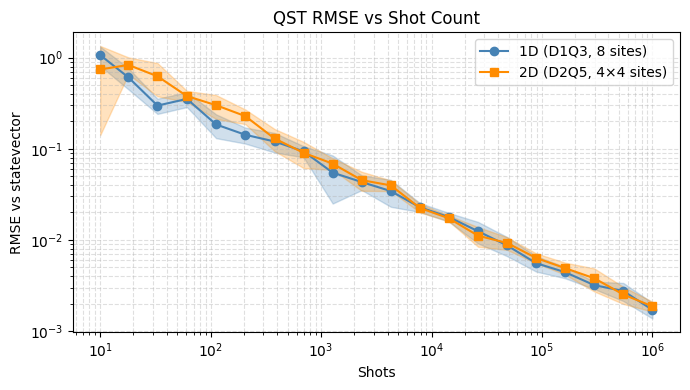

In [110]:
# ── RMSE plot (1D + 2D combined) ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.loglog(SHOT_COUNTS, rmse_mean_1d, marker='o', color='steelblue',
          label='1D (D1Q3, 8 sites)')
ax.fill_between(
    SHOT_COUNTS,
    np.maximum(rmse_mean_1d - rmse_std_1d, 1e-10),
    rmse_mean_1d + rmse_std_1d,
    alpha=0.25, color='steelblue'
)
ax.loglog(SHOT_COUNTS, rmse_mean_2d, marker='s', color='darkorange',
          label='2D (D2Q5, 4×4 sites)')
ax.fill_between(
    SHOT_COUNTS,
    np.maximum(rmse_mean_2d - rmse_std_2d, 1e-10),
    rmse_mean_2d + rmse_std_2d,
    alpha=0.25, color='darkorange'
)

ax.set_xlabel('Shots')
ax.set_ylabel('RMSE vs statevector')
ax.set_title('QST RMSE vs Shot Count')
ax.legend()
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('papers/disertation/master/src/img/figures/qst_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

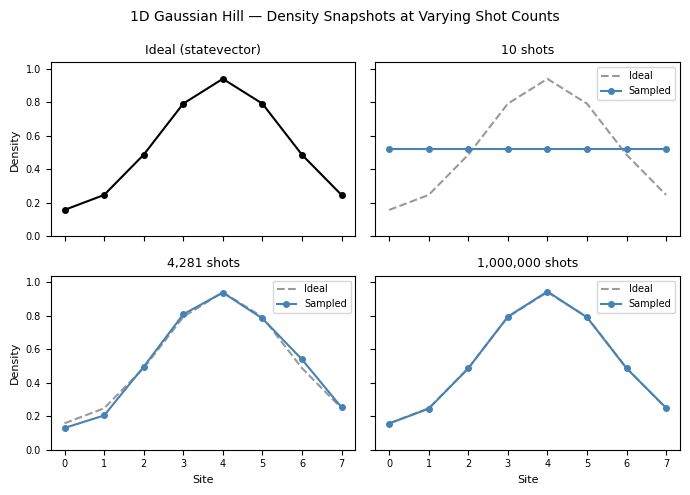

In [111]:
# ── 1D density snapshots (2×2) ────────────────────────────────────────────────
snapshot_shots_1d = [SHOT_COUNTS[0], SHOT_COUNTS[len(SHOT_COUNTS) // 2], SHOT_COUNTS[-1]]
x = np.arange(SITES_1D)

# Pre-generate so ymax reflects actual sampled maxima
snapshots_1d = [
    qlbm.simulate_flow_sampled(initial_density_1d, config_1d, int(s))[0].flatten()
    for s in snapshot_shots_1d
]
ymax = max(ideal_density_1d.max(), *(s.max() for s in snapshots_1d)) * 1.1

fig, axes = plt.subplots(2, 2, figsize=(7, 5), sharey=True, sharex=True)
axes_flat = axes.flatten()

axes_flat[0].plot(x, ideal_density_1d, color='black', marker='o', markersize=4)
axes_flat[0].set_title('Ideal (statevector)', fontsize=9)
axes_flat[0].set_ylim(0, ymax)
axes_flat[0].tick_params(labelsize=7)

for ax, shots, density_est in zip(axes_flat[1:], snapshot_shots_1d, snapshots_1d):
    ax.plot(x, ideal_density_1d, color='black', linestyle='--', alpha=0.4, label='Ideal')
    ax.plot(x, density_est, color='steelblue', marker='o', markersize=4, label='Sampled')
    ax.set_title(f'{shots:,} shots', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

for ax in axes[1, :]:   # bottom row: x labels
    ax.set_xlabel('Site', fontsize=8)
for ax in axes[:, 0]:   # left column: y labels
    ax.set_ylabel('Density', fontsize=8)

plt.suptitle('1D Gaussian Hill — Density Snapshots at Varying Shot Counts', fontsize=10)
plt.tight_layout()
plt.savefig('papers/disertation/master/src/img/figures/qst_1d_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

## 2D — Periodic Gaussian Hill (D2Q5, 4×4 sites)

In [112]:
# ── 2D config ─────────────────────────────────────────────────────────────────
SITES_2D = (4, 4)

links_2d   = [[0, 0], [1, 0], [-1, 0], [0, 1], [0, -1]]
weights_2d = [1/3, 1/6, 1/6, 1/6, 1/6]
cs_2d      = 1 / np.sqrt(3)

initial_density_2d = get_gaussian_2d_initial_distribution(
    sites=SITES_2D,
    center=(1.5, 1.5),
    width=1.0,
    amplitude=0.9,
    background=0.1,
)
velocity_field_2d = np.zeros((2, *SITES_2D))

config_2d = [(1, velocity_field_2d, links_2d, weights_2d, cs_2d, None)]

In [113]:
# ── 2D ideal reference density (statevector) ──────────────────────────────────
with tempfile.NamedTemporaryFile(suffix='.csv', delete=False, mode='w') as f:
    tmp_2d = f.name

qlbm.simulate_flow(initial_density_2d, config_2d, tmp_2d)
ideal_flat_2d    = pd.read_csv(tmp_2d, header=None).iloc[1].values.astype(float)
ideal_density_2d = ideal_flat_2d.reshape(SITES_2D, order='F')
os.unlink(tmp_2d)

print("Ideal 2D density shape:", ideal_density_2d.shape)

Pre-building all circuit components for 1 configuration(s)...
  Building components for configuration 1/1...
    Components built and transpiled.
Pre-building complete. 1 unique component set(s) created.
Starting simulation...

Configuration 1/1: iterations 1-1/1
Iteration 1 running...
Ideal 2D density shape: (4, 4)


In [114]:
# ── 2D shot sweep ─────────────────────────────────────────────────────────────
rmse_mean_2d            = []
rmse_std_2d             = []
ancilla_discard_mean_2d = []
ancilla_discard_std_2d  = []

for shots in SHOT_COUNTS:
    trial_rmse    = []
    trial_discard = []
    for _ in range(NUM_TRIALS):
        density_est, stats = qlbm.simulate_flow_sampled(initial_density_2d, config_2d, int(shots))
        trial_rmse.append(np.sqrt(np.mean((density_est - ideal_density_2d) ** 2)))
        trial_discard.append(stats['ancilla_discard_fraction'])
    rmse_mean_2d.append(np.mean(trial_rmse))
    rmse_std_2d.append(np.std(trial_rmse))
    ancilla_discard_mean_2d.append(np.mean(trial_discard))
    ancilla_discard_std_2d.append(np.std(trial_discard))
    print(f"shots={shots:>8d}  RMSE={np.mean(trial_rmse):.4f} ± {np.std(trial_rmse):.4f}  "
          f"ancilla_discard={np.mean(trial_discard):.3f}")

rmse_mean_2d            = np.array(rmse_mean_2d)
rmse_std_2d             = np.array(rmse_std_2d)
ancilla_discard_mean_2d = np.array(ancilla_discard_mean_2d)
ancilla_discard_std_2d  = np.array(ancilla_discard_std_2d)

shots=      10  RMSE=0.8593 ± 0.5167  ancilla_discard=0.740
shots=      18  RMSE=0.9591 ± 0.1642  ancilla_discard=0.789
shots=      33  RMSE=0.6225 ± 0.1709  ancilla_discard=0.752
shots=      61  RMSE=0.3897 ± 0.0750  ancilla_discard=0.748
shots=     112  RMSE=0.2652 ± 0.0285  ancilla_discard=0.729
shots=     206  RMSE=0.2377 ± 0.0406  ancilla_discard=0.740
shots=     379  RMSE=0.1467 ± 0.0313  ancilla_discard=0.753
shots=     695  RMSE=0.1095 ± 0.0136  ancilla_discard=0.739
shots=    1274  RMSE=0.0724 ± 0.0159  ancilla_discard=0.751
shots=    2335  RMSE=0.0480 ± 0.0131  ancilla_discard=0.755
shots=    4281  RMSE=0.0338 ± 0.0049  ancilla_discard=0.754
shots=    7847  RMSE=0.0219 ± 0.0046  ancilla_discard=0.749
shots=   14384  RMSE=0.0158 ± 0.0009  ancilla_discard=0.748
shots=   26366  RMSE=0.0126 ± 0.0015  ancilla_discard=0.750
shots=   48329  RMSE=0.0085 ± 0.0012  ancilla_discard=0.751
shots=   88586  RMSE=0.0064 ± 0.0014  ancilla_discard=0.750
shots=  162377  RMSE=0.0052 ± 0.0017  an

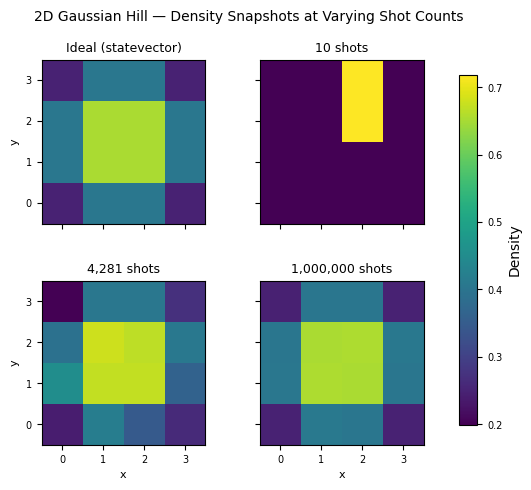

In [115]:
# ── 2D density snapshots (2×2) ────────────────────────────────────────────────
snapshot_shots_2d = [SHOT_COUNTS[0], SHOT_COUNTS[len(SHOT_COUNTS) // 2], SHOT_COUNTS[-1]]

vmin = ideal_density_2d.min() * 0.8
vmax = ideal_density_2d.max() * 1.1
yticks = list(range(SITES_2D[1]))
xticks = list(range(SITES_2D[0]))

fig, axes = plt.subplots(2, 2, figsize=(6, 5))
fig.subplots_adjust(right=0.82, hspace=0.35, wspace=0.1)
axes_flat = axes.flatten()

im = axes_flat[0].imshow(ideal_density_2d.T, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
axes_flat[0].set_title('Ideal (statevector)', fontsize=9)
axes_flat[0].set_yticks(yticks)
axes_flat[0].set_xticks(xticks)
axes_flat[0].tick_params(labelsize=7)

for ax, shots in zip(axes_flat[1:], snapshot_shots_2d):
    density_est, _ = qlbm.simulate_flow_sampled(initial_density_2d, config_2d, int(shots))
    ax.imshow(density_est.T, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(f'{shots:,} shots', fontsize=9)
    ax.set_yticks(yticks)
    ax.set_xticks(xticks)
    ax.tick_params(labelsize=7)

# x labels on bottom row only, y labels on left column only
for ax in axes[0, :]:
    ax.tick_params(labelbottom=False)
for ax in axes[:, 1]:
    ax.tick_params(labelleft=False)
for ax in axes[1, :]:
    ax.set_xlabel('x', fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel('y', fontsize=8)

cax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cax, label='Density')
cax.tick_params(labelsize=7)

plt.suptitle('2D Gaussian Hill — Density Snapshots at Varying Shot Counts', fontsize=10)
plt.savefig('papers/disertation/master/src/img/figures/qst_2d_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

## Ancilla (collision oracle) discard statistics

The macros gate is omitted from the shot-based path. Density is recovered by
classically summing counts over all link states for each site (the site-qubit
marginal), so link-qubit outcomes are never discarded. The only remaining
post-selection cost is the ancilla qubit used as the collision oracle (LCU):
shots where the ancilla measures |1⟩ are discarded.

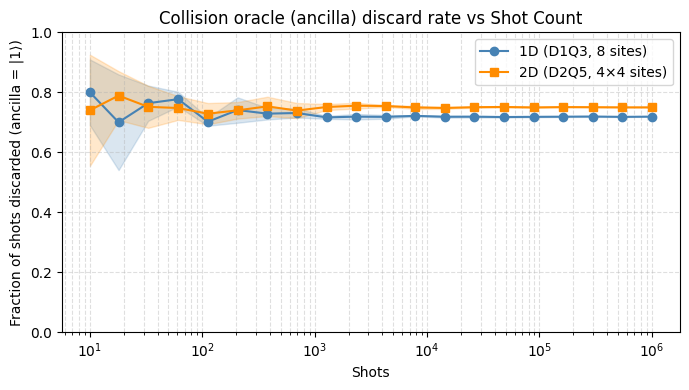

In [116]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.semilogx(SHOT_COUNTS, ancilla_discard_mean_1d, marker='o', color='steelblue',
            label='1D (D1Q3, 8 sites)')
ax.fill_between(
    SHOT_COUNTS,
    np.clip(ancilla_discard_mean_1d - ancilla_discard_std_1d, 0, 1),
    np.clip(ancilla_discard_mean_1d + ancilla_discard_std_1d, 0, 1),
    alpha=0.2, color='steelblue'
)
ax.semilogx(SHOT_COUNTS, ancilla_discard_mean_2d, marker='s', color='darkorange',
            label='2D (D2Q5, 4×4 sites)')
ax.fill_between(
    SHOT_COUNTS,
    np.clip(ancilla_discard_mean_2d - ancilla_discard_std_2d, 0, 1),
    np.clip(ancilla_discard_mean_2d + ancilla_discard_std_2d, 0, 1),
    alpha=0.2, color='darkorange'
)

ax.set_xlabel('Shots')
ax.set_ylabel('Fraction of shots discarded (ancilla = |1⟩)')
ax.set_title('Collision oracle (ancilla) discard rate vs Shot Count')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('papers/disertation/master/src/img/figures/qst_discard.png', dpi=150, bbox_inches='tight')
plt.show()

In [117]:
# ── LaTeX table rows ──────────────────────────────────────────────────────────
print("% Paste into tab:qst_rmse")
print(r"\hline")
for shots, r1m, r1s, d1m, d1s, r2m, r2s, d2m, d2s in zip(
    SHOT_COUNTS,
    rmse_mean_1d, rmse_std_1d, ancilla_discard_mean_1d, ancilla_discard_std_1d,
    rmse_mean_2d, rmse_std_2d, ancilla_discard_mean_2d, ancilla_discard_std_2d,
):
    shots_fmt = f"{shots:,}".replace(",", "{,}")
    print(
        f"{shots_fmt:>20} "
        f"& {r1m:.4f} & {r1s:.4f} & {d1m:.4f} & {d1s:.4f} "
        f"& {r2m:.4f} & {r2s:.4f} & {d2m:.4f} & {d2s:.4f} \\\\"
    )
print(r"\hline")

% Paste into tab:qst_rmse
\hline
                  10 & 1.0670 & 0.2560 & 0.8000 & 0.1095 & 0.8593 & 0.5167 & 0.7400 & 0.1855 \\
                  18 & 0.6079 & 0.1585 & 0.7000 & 0.1595 & 0.9591 & 0.1642 & 0.7889 & 0.0816 \\
                  33 & 0.2979 & 0.0564 & 0.7636 & 0.0588 & 0.6225 & 0.1709 & 0.7515 & 0.0702 \\
                  61 & 0.3528 & 0.0656 & 0.7770 & 0.0245 & 0.3897 & 0.0750 & 0.7475 & 0.0396 \\
                 112 & 0.1849 & 0.0540 & 0.7018 & 0.0134 & 0.2652 & 0.0285 & 0.7286 & 0.0355 \\
                 206 & 0.1425 & 0.0284 & 0.7408 & 0.0424 & 0.2377 & 0.0406 & 0.7398 & 0.0276 \\
                 379 & 0.1203 & 0.0291 & 0.7288 & 0.0193 & 0.1467 & 0.0313 & 0.7530 & 0.0322 \\
                 695 & 0.0937 & 0.0131 & 0.7309 & 0.0149 & 0.1095 & 0.0136 & 0.7390 & 0.0252 \\
             1{,}274 & 0.0547 & 0.0297 & 0.7163 & 0.0049 & 0.0724 & 0.0159 & 0.7509 & 0.0101 \\
             2{,}335 & 0.0432 & 0.0079 & 0.7187 & 0.0091 & 0.0480 & 0.0131 & 0.7553 & 0.0097 \\
       